In [2]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

In [3]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'three0'
    date: str =  '250313'
    img_size = 384
    ks = [1, 10, 50] #, 100, 200, 500]
    folder_name = 'talia_20each_tizi' # 'fewer_occlusion'
    new_fs = 100
    n_subsamples = range(50, 701, 50)
    n_iterations = 20
    RDM_metric_signal = 'cosine_cnt'
    RDM_metric_model = 'cosine_cnt'
    RSA_metric = 'correlation'
    brain_area = "AIT"
    model_name = 'vit_l_16'
    pkg = 'timm'
    img_size = 384
    pooling = 'mean'
    layer_name = 'blocks.12.mlp.fc2'
    drsa_timepoint_idx = 17
    cka_signal_metric = 'cosine_cnt'
    cka_model_metric = 'cosine_cnt'
    cka_method = 'biased'
    cka_signal_metric_type = 'distance'
    cka_model_metric_type = 'distance'
    dcka_timepoint_idx = 17
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
layers = [layers[i] for i in [2, 12, 22]]

# Effect of subsample size on static dCKA

This shows static dCKA at the configured timepoint across the same subsample sizes and number of iterations. Static dCKA has no $k$ parameter.

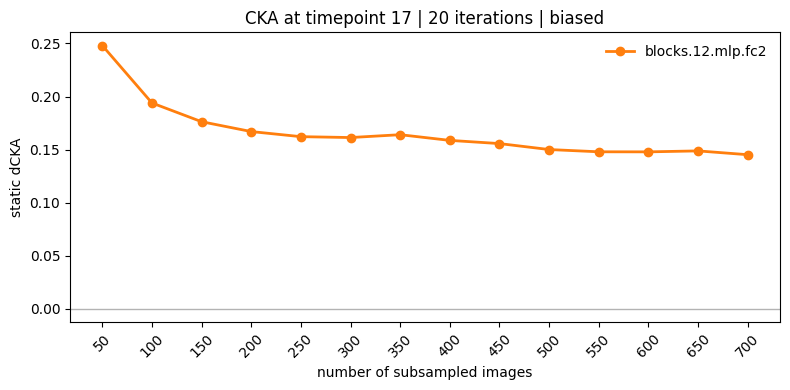

In [4]:
from II_analyses.static_dyn import static_dCKA_save_name

# Show static dCKA at one representative timepoint across subsample sizes.
fig, ax = plt.subplots(figsize=(8, 4))
available_subsamples = []
dcka_by_subsample_size = []
for n_subsamples in cfg.n_subsamples:
    dcka_fn = static_dCKA_save_name(
        paths,
        cfg.cka_signal_metric,
        cfg.cka_model_metric,
        cfg.cka_method,
        cfg.cka_signal_metric_type,
        cfg.cka_model_metric_type,
        cfg.monkey_name,
        cfg.date,
        cfg.brain_area,
        cfg.model_name,
        cfg.img_size,
        cfg.layer_name,
        cfg.new_fs,
        subsamples_size=n_subsamples,
        n_iterations=cfg.n_iterations,
    )
    try:
        dcka = np.load(dcka_fn)["arr_0"]
    except FileNotFoundError:
        print(f"failed to load {dcka_fn}")
        continue
    # end try

    if cfg.dcka_timepoint_idx >= dcka.shape[-1]:
        raise IndexError(
            f"dcka_timepoint_idx={cfg.dcka_timepoint_idx} exceeds "
            f"the available dCKA timepoints ({dcka.shape[-1]})"
        )
    # end if cfg.dcka_timepoint_idx >= dcka.shape[-1]

    available_subsamples.append(n_subsamples)
    dcka_by_subsample_size.append(dcka[cfg.dcka_timepoint_idx])
# end for n_subsamples in cfg.n_subsamples

ax.plot(
    available_subsamples,
    dcka_by_subsample_size,
    color="tab:orange",
    marker="o",
    linewidth=2,
    label=cfg.layer_name,
)

ax.axhline(0, color="0.7", linewidth=1)
ax.set_xticks(
    list(cfg.n_subsamples),
    labels=list(cfg.n_subsamples),
    rotation=45,
)
ax.set_title(
    f"CKA at timepoint {cfg.dcka_timepoint_idx} | "
    f"{cfg.n_iterations} iterations | {cfg.cka_method}"
)
ax.set_xlabel("number of subsampled images")
ax.set_ylabel("static dCKA")
ax.legend(frameon=False)
plt.tight_layout()

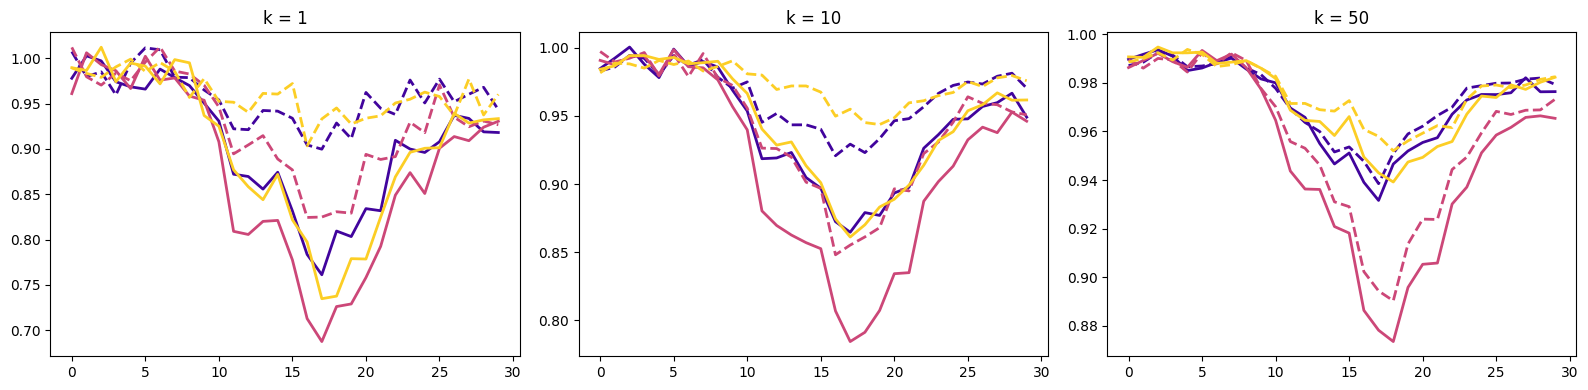

In [5]:
from useful_stuff.general_utils.plots import truncate_colormap
base_cmap = plt.cm.plasma

cmap = truncate_colormap(base_cmap, 0.10, 0.90)
fig, ax = plt.subplots(1,len(cfg.ks), figsize=(16, 4))
for idx_k, k in enumerate(cfg.ks):
    for i_col, l in enumerate(layers):
        color = cmap(i_col / (len(layers) - 1))
        try:
            A2B_fn = f"{paths['data_path']}/results/dynII_A2B_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz_{cfg.n_subsamples[3]}subsamples_{cfg.n_iterations}iterations.npz"
            B2A_fn = f"{paths['data_path']}/results/dynII_B2A_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz_{cfg.n_subsamples[3]}subsamples_{cfg.n_iterations}iterations.npz"
            A2B = np.load(A2B_fn)["arr_0"]
            B2A = np.load(B2A_fn)["arr_0"]
            if k == cfg.ks[-1]:
                ax[idx_k].plot(A2B, color=color, linewidth=2, label=l, linestyle="--")
                ax[idx_k].plot(B2A, color=color, label=l, linewidth=2)
            else:
                ax[idx_k].plot(A2B, color=color, linewidth=2, linestyle="--")
                ax[idx_k].plot(B2A, color=color, linewidth=2)
            
            ax[idx_k].set_title(f"k = {k}")
            # ax[idx_k].set_ylim([1, .6])
        except FileNotFoundError:
            print(f"failed to load {A2B_fn}")
            pass
    
# fig.legend(
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5),
#     frameon=False
# );
plt.tight_layout()
# /Users/tizianocausin/metrics_II_local/results/dynII_A2B_k1_euclidean-euclidean_three0_250313_AIT_vit_l_16_384_blocks.23.mlp.fc2_100Hz_400subsamples_20iterations.npz

In [6]:
len(cfg.n_subsamples)

14

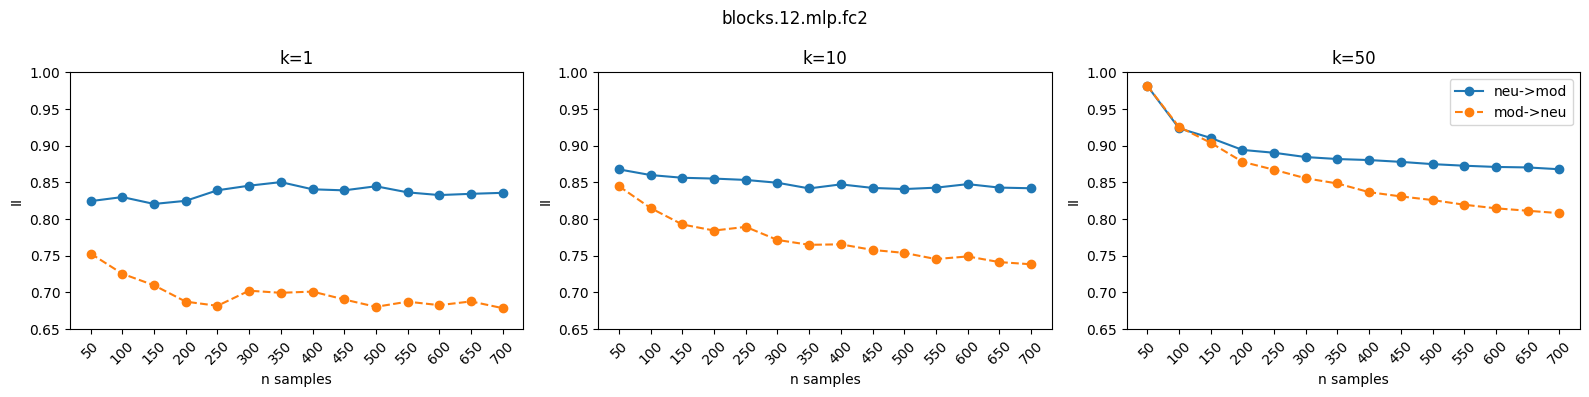

In [7]:
fig, ax = plt.subplots(1,len(cfg.ks), figsize=(16, 4))
n_subsamples = list(cfg.n_subsamples)                                                              
x_positions = np.arange(len(n_subsamples))

for idx_k, k in enumerate(cfg.ks):
    n_list_A2B =[] 
    n_list_B2A =[] 
    for idx_n, n in enumerate(cfg.n_subsamples):
        color = cmap(i_col / (len(layers) - 1))
        A2B_fn = f"{paths['data_path']}/results/dynII_A2B_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{cfg.layer_name}_{cfg.new_fs}Hz_{n}subsamples_{cfg.n_iterations}iterations.npz"
        B2A_fn = f"{paths['data_path']}/results/dynII_B2A_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{cfg.layer_name}_{cfg.new_fs}Hz_{n}subsamples_{cfg.n_iterations}iterations.npz"
        A2B = np.min(np.load(A2B_fn)["arr_0"])
        B2A = np.min(np.load(B2A_fn)["arr_0"])
        A2B = np.load(A2B_fn)["arr_0"][17]
        B2A = np.load(B2A_fn)["arr_0"][17]
        n_list_A2B.append(A2B)
        n_list_B2A.append(B2A)
    if k == cfg.ks[-1]:
        ax[idx_k].plot(n_list_A2B, marker="o", label="neu->mod")
        ax[idx_k].plot(n_list_B2A, linestyle="--", marker="o", label="mod->neu")
    else:
        ax[idx_k].plot(n_list_A2B, marker="o")
        ax[idx_k].plot(n_list_B2A, linestyle="--", marker="o")
    ax[idx_k].set_xticks(
        x_positions,
        labels=n_subsamples,
        rotation=45,
    )
    ax[idx_k].set_ylim([.65, 1])
    ax[idx_k].set_title(f"k={k}")
    ax[idx_k].set_ylabel("II")
    ax[idx_k].set_xlabel("n samples")
fig.suptitle(f"{cfg.layer_name}")
plt.legend()
plt.tight_layout()
    

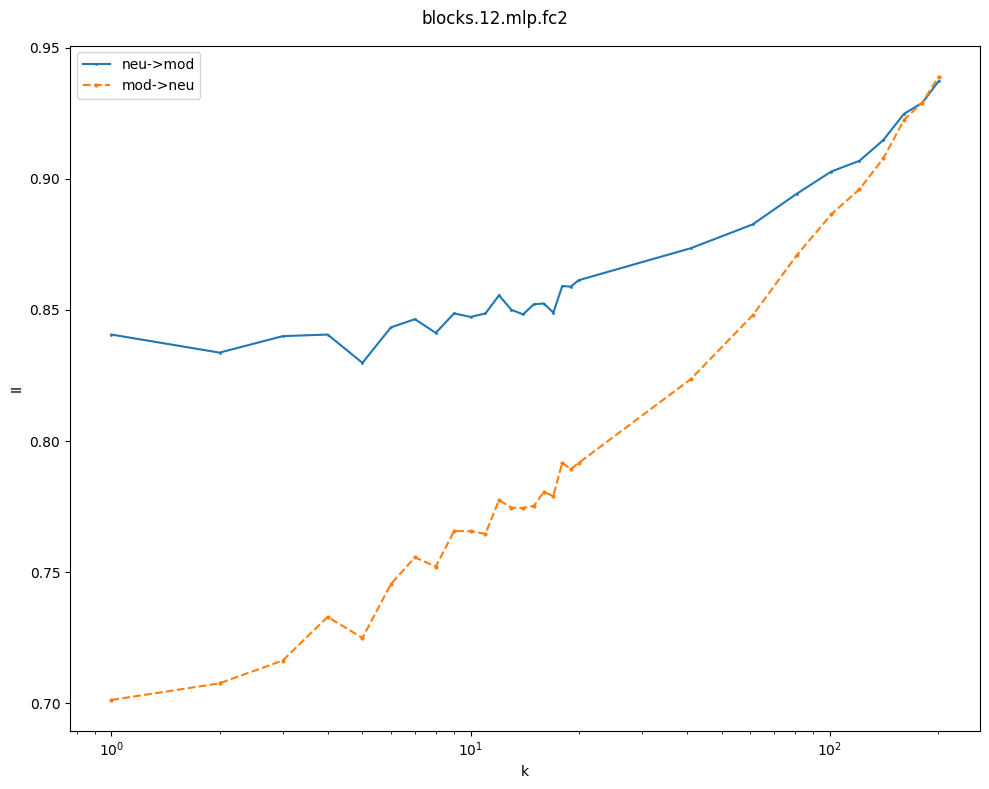

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))
n_subsamples = list(cfg.n_subsamples)                                                              
x_positions = np.arange(len(n_subsamples))

n_list_A2B =[] 
n_list_B2A =[] 
k_range = np.concatenate((np.arange(1,21), np.arange(41,202,20)))
for idx_k, k in enumerate(k_range):
    
    color = cmap(i_col / (len(layers) - 1))
    A2B_fn = f"{paths['data_path']}/results/dynII_A2B_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{cfg.layer_name}_{cfg.new_fs}Hz_{400}subsamples_{cfg.n_iterations}iterations.npz"
    B2A_fn = f"{paths['data_path']}/results/dynII_B2A_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{cfg.layer_name}_{cfg.new_fs}Hz_{400}subsamples_{cfg.n_iterations}iterations.npz"
    A2B = np.min(np.load(A2B_fn)["arr_0"])
    B2A = np.min(np.load(B2A_fn)["arr_0"])
    A2B = np.load(A2B_fn)["arr_0"][17]
    B2A = np.load(B2A_fn)["arr_0"][17]
    n_list_A2B.append(A2B)
    n_list_B2A.append(B2A)
    
# Plot the actual k values so the unequal sampling steps are represented correctly.
ax.plot(k_range, n_list_A2B, marker="o", markersize=1, label="neu->mod")
ax.plot(k_range, n_list_B2A, linestyle="--", marker="o", markersize=2, label="mod->neu")
ax.set_xscale("log")
ax.set_xlabel("k")
ax.set_ylabel("II")

fig.suptitle(f"{cfg.layer_name}")
ax.legend()
fig.tight_layout()
    

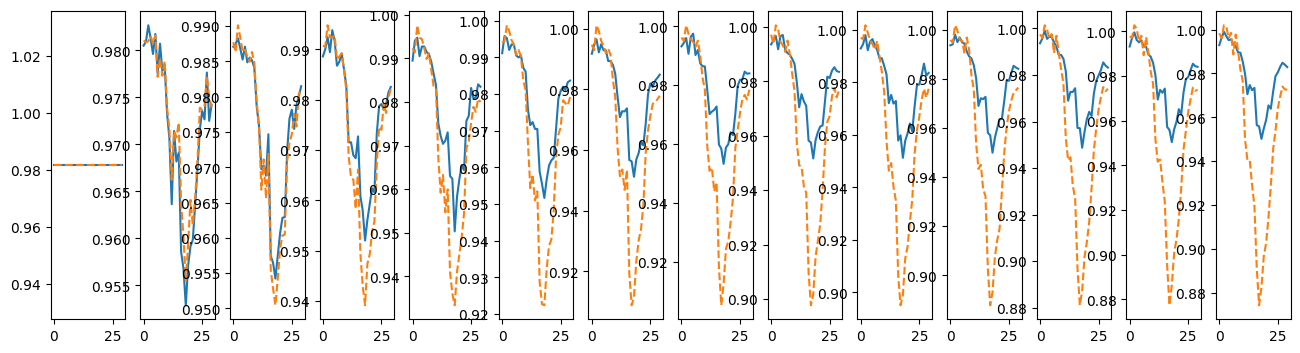

In [7]:
fig, ax = plt.subplots(1,len(cfg.n_subsamples), figsize=(16, 4))
# for idx_k, k in enumerate(cfg.ks):
n_list_A2B =[] 
n_list_B2A =[] 
for idx_n, n in enumerate(cfg.n_subsamples):
    color = cmap(i_col / (len(layers) - 1))
    A2B_fn = f"{paths['data_path']}/results/dynII_A2B_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz_{n}subsamples_{cfg.n_iterations}iterations.npz"
    B2A_fn = f"{paths['data_path']}/results/dynII_B2A_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz_{n}subsamples_{cfg.n_iterations}iterations.npz"
    A2B = np.load(A2B_fn)["arr_0"]
    B2A = np.load(B2A_fn)["arr_0"]
    ax[idx_n].plot(A2B)
    ax[idx_n].plot(B2A, linestyle="--")

#     n_list_A2B.append(A2B)
#     n_list_B2A.append(B2A)
# ax[idx_k].plot(n_list_A2B)
# ax[idx_k].plot(n_list_B2A, linestyle="--")

failed to load /Users/tizianocausin/metrics_II_local/results/dynII_A2B_k1_cosine_cnt-cosine_cnt_three0_250313_AIT_vit_l_16_384_blocks.22.mlp.fc2_100Hz_200subsamples_50iterations.npz
failed to load /Users/tizianocausin/metrics_II_local/results/dynII_A2B_k1_cosine_cnt-cosine_cnt_three0_250313_AIT_vit_l_16_384_blocks.22.mlp.fc2_100Hz_200subsamples_100iterations.npz
failed to load /Users/tizianocausin/metrics_II_local/results/dynII_A2B_k1_cosine_cnt-cosine_cnt_three0_250313_AIT_vit_l_16_384_blocks.22.mlp.fc2_100Hz_200subsamples_150iterations.npz
failed to load /Users/tizianocausin/metrics_II_local/results/dynII_A2B_k1_cosine_cnt-cosine_cnt_three0_250313_AIT_vit_l_16_384_blocks.22.mlp.fc2_100Hz_200subsamples_200iterations.npz
failed to load /Users/tizianocausin/metrics_II_local/results/dynII_A2B_k1_cosine_cnt-cosine_cnt_three0_250313_AIT_vit_l_16_384_blocks.22.mlp.fc2_100Hz_200subsamples_250iterations.npz
failed to load /Users/tizianocausin/metrics_II_local/results/dynII_A2B_k1_cosine_cnt-c

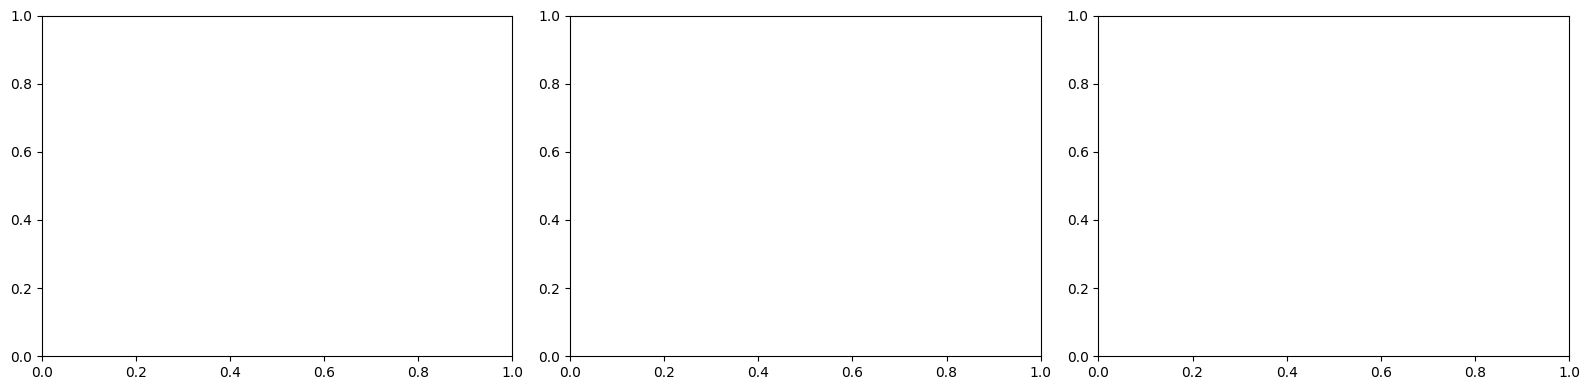

In [8]:
from useful_stuff.general_utils.plots import truncate_colormap
base_cmap = plt.cm.plasma

cmap = truncate_colormap(base_cmap, 0.10, 0.90)
fig, ax = plt.subplots(1,len(cfg.ks), figsize=(16, 4))
for idx_k, k in enumerate(cfg.ks):
    for idx_n, n in enumerate(cfg.n_subsamples):
        color = cmap(i_col / (len(layers) - 1))
        try:
            A2B_fn = f"{paths['data_path']}/results/dynII_A2B_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz_{cfg.n_subsamples[3]}subsamples_{n}iterations.npz"
            B2A_fn = f"{paths['data_path']}/results/dynII_B2A_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz_{cfg.n_subsamples[3]}subsamples_{n}iterations.npz"
            A2B = np.load(A2B_fn)["arr_0"]
            B2A = np.load(B2A_fn)["arr_0"]
            if k == cfg.ks[-1]:
                ax[idx_k].plot(A2B, color=color, linewidth=2, label=l, linestyle="--")
                ax[idx_k].plot(B2A, color=color, label=l, linewidth=2)
            else:
                ax[idx_k].plot(A2B, color=color, linewidth=2, linestyle="--")
                ax[idx_k].plot(B2A, color=color, linewidth=2)
            
            ax[idx_k].set_title(f"k = {k}")
            # ax[idx_k].set_ylim([1, .6])
        except FileNotFoundError:
            print(f"failed to load {A2B_fn}")
            pass
    
# fig.legend(
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5),
#     frameon=False
# );
plt.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_cosine_cnt-cosine_cnt_three0_250313_AIT_vit_l_16_384_blocks.2.mlp.fc2_100Hz.npz'

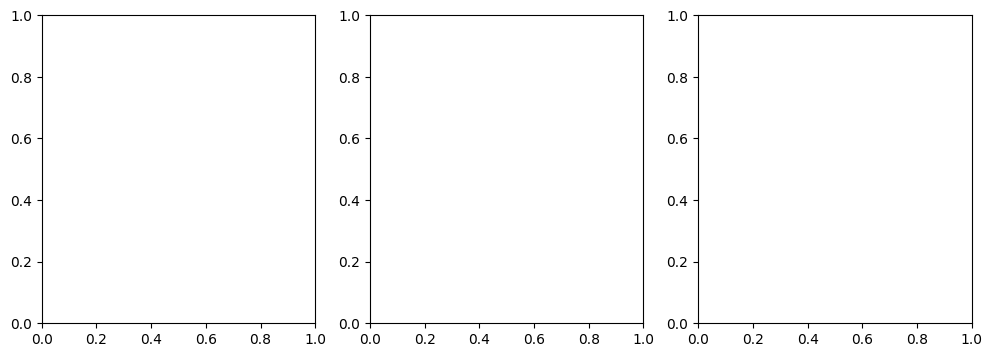

In [14]:
from useful_stuff.general_utils.plots import truncate_colormap
base_cmap = plt.cm.Reds

cmap = truncate_colormap(base_cmap, 0.10, 0.90)
fig, ax = plt.subplots(1,3, figsize=(12, 4))
for idx_k, k in enumerate(cfg.ks):
    A2B_tot = []
    B2A_tot = []
    RSA_tot = []
    color = cmap(idx_k / (len(cfg.ks) - 1))
    for l in layers:
        A2B_fn = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        B2A_fn = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{k}_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        RSA_fn = f"{paths['livingstone_lab']}/tiziano/results/static_dRSA_{cfg.RDM_metric_signal}-{cfg.RDM_metric_model}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        A2B = np.min(np.load(A2B_fn)["arr_0"])
        B2A = np.min(np.load(B2A_fn)["arr_0"])
        RSA = np.max(np.load(RSA_fn)["arr_0"])
        A2B_tot.append(A2B)
        B2A_tot.append(B2A)
        RSA_tot.append(RSA)
    ax[0].plot(A2B_tot, color=color, label=f"k={k}")
    ax[1].plot(B2A_tot, color=color,)
    ax[2].plot(RSA_tot, color="tab:blue",)
fig.supylabel("Information Imbalance")
fig.supxlabel("layer idx")
ax[0].set_title("neural -> model")
ax[1].set_title("model -> neural")
ax[2].set_title("RSA")

fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
);
plt.tight_layout()

In [ ]:
np.corrcoef(A2B_tot, RSA_tot)

# Effect of subsample size on static dRSA

This mirrors the number-of-samples plot above using static dRSA at the configured timepoint. Static dRSA has no $k$ parameter.

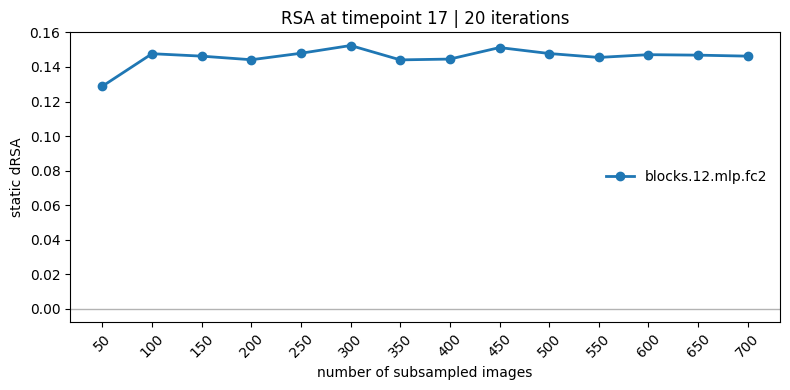

In [10]:
from II_analyses.static_dyn import static_dRSA_save_name

# Show static dRSA at the same representative timepoint across subsample sizes.
fig, ax = plt.subplots(figsize=(8, 4))
available_subsamples = []
drsa_by_subsample_size = []
for n_subsamples in cfg.n_subsamples:
    drsa_fn = static_dRSA_save_name(
        paths,
        cfg.RDM_metric_signal,
        cfg.RDM_metric_model,
        cfg.monkey_name,
        cfg.date,
        cfg.brain_area,
        cfg.model_name,
        cfg.img_size,
        cfg.layer_name,
        cfg.new_fs,
        subsamples_size=n_subsamples,
        n_iterations=cfg.n_iterations,
    )
    try:
        drsa = np.load(drsa_fn)["arr_0"]
    except FileNotFoundError:
        print(f"failed to load {drsa_fn}")
        continue
    # end try

    if cfg.drsa_timepoint_idx >= drsa.shape[-1]:
        raise IndexError(
            f"drsa_timepoint_idx={cfg.drsa_timepoint_idx} exceeds "
            f"the available dRSA timepoints ({drsa.shape[-1]})"
        )
    # end if cfg.drsa_timepoint_idx >= drsa.shape[-1]

    available_subsamples.append(n_subsamples)
    drsa_by_subsample_size.append(drsa[cfg.drsa_timepoint_idx])
# end for n_subsamples in cfg.n_subsamples

ax.plot(
    available_subsamples,
    drsa_by_subsample_size,
    color="tab:blue",
    marker="o",
    linewidth=2,
    label=cfg.layer_name,
)

ax.axhline(0, color="0.7", linewidth=1)
ax.set_xticks(
    list(cfg.n_subsamples),
    labels=list(cfg.n_subsamples),
    rotation=45,
)
ax.set_title(
    f"RSA at timepoint {cfg.drsa_timepoint_idx} | "
    f"{cfg.n_iterations} iterations"
)
ax.set_xlabel("number of subsampled images")
ax.set_ylabel("static dRSA")
ax.legend(frameon=False)
plt.tight_layout()